# I. Import libraries

In [105]:
import xgboost as xgb
import numpy as np
from collections import OrderedDict
import gc
from glob import glob
import os
import pandas as pd
from copy import copy
from time import time
from sklearn.metrics import roc_auc_score,confusion_matrix,accuracy_score,classification_report,roc_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from timeit import default_timer
import matplotlib.pyplot as plt
import pickle

# Set the seed for numpy
np.random.seed(123)

# Display all columns of Pandas' dataframes by default
pd.set_option('display.max_columns', None)

data_path = '/kaggle/input/kdd99-dataset/kddcup99_csv.csv'

# II. Dataset preparation

In [106]:
col_names = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
             "num_compromised","root_shell","su_attempted","num_root","num_file_creations","num_shells","num_access_files","num_outbound_cmds",
             "is_host_login","is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
             "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate","dst_host_diff_srv_rate",
             "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate",
             "dst_host_srv_rerror_rate","label"]

df = pd.read_csv(data_path, header=0, names=col_names, index_col=False, low_memory=False)

df.head(5)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,9,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal
1,0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,19,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.0,0.0,0.0,0.0,1.0,0.0,0.0,29,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,39,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.0,0.0,0.0,0.0,1.0,0.0,0.0,49,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal


In [107]:
df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,root_shell,su_attempted,num_root,num_file_creations,num_shells,num_access_files,num_outbound_cmds,is_host_login,is_guest_login,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,http,SF,181,5450,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.0,0.0,1.0,0.0,0.00,9,9,1.0,0.0,0.11,0.00,0.00,0.00,0.0,0.0,normal
1,0,tcp,http,SF,239,486,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.0,0.0,1.0,0.0,0.00,19,19,1.0,0.0,0.05,0.00,0.00,0.00,0.0,0.0,normal
2,0,tcp,http,SF,235,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,8,8,0.00,0.00,0.0,0.0,1.0,0.0,0.00,29,29,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
3,0,tcp,http,SF,219,1337,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.0,0.0,1.0,0.0,0.00,39,39,1.0,0.0,0.03,0.00,0.00,0.00,0.0,0.0,normal
4,0,tcp,http,SF,217,2032,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.0,0.0,1.0,0.0,0.00,49,49,1.0,0.0,0.02,0.00,0.00,0.00,0.0,0.0,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494015,0,tcp,http,SF,310,1881,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,4,5,0.00,0.00,0.0,0.0,1.0,0.0,0.40,86,255,1.0,0.0,0.01,0.05,0.00,0.01,0.0,0.0,normal
494016,0,tcp,http,SF,282,2286,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,6,0.00,0.00,0.0,0.0,1.0,0.0,0.00,6,255,1.0,0.0,0.17,0.05,0.00,0.01,0.0,0.0,normal
494017,0,tcp,http,SF,203,1200,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,18,0.17,0.11,0.0,0.0,1.0,0.0,0.17,16,255,1.0,0.0,0.06,0.05,0.06,0.01,0.0,0.0,normal
494018,0,tcp,http,SF,291,1200,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,6,12,0.00,0.00,0.0,0.0,1.0,0.0,0.17,26,255,1.0,0.0,0.04,0.05,0.04,0.01,0.0,0.0,normal


In [108]:
df['label'].value_counts()

label
smurf              280790
neptune            107201
normal              97277
back                 2203
satan                1589
ipsweep              1247
portsweep            1040
warezclient          1020
teardrop              979
pod                   264
nmap                  231
guess_passwd           53
buffer_overflow        30
land                   21
warezmaster            20
imap                   12
rootkit                10
loadmodule              9
ftp_write               8
multihop                7
phf                     4
perl                    3
spy                     2
Name: count, dtype: int64

In [109]:
le = LabelEncoder().fit(df.label)
print(le.classes_)

['back' 'buffer_overflow' 'ftp_write' 'guess_passwd' 'imap' 'ipsweep'
 'land' 'loadmodule' 'multihop' 'neptune' 'nmap' 'normal' 'perl' 'phf'
 'pod' 'portsweep' 'rootkit' 'satan' 'smurf' 'spy' 'teardrop'
 'warezclient' 'warezmaster']


In [110]:
# Capture the categorical variables and One-hot Encode them
cat_vars = ['protocol_type', 'service', 'flag', 'land', 'logged_in','is_host_login', 'is_guest_login']
cat_data = pd.get_dummies(df[cat_vars]).astype(int) # One-hot Encode

cat_data.head()

,land,logged_in,is_host_login,is_guest_login,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_auth,service_bgp,service_courier,service_csnet_ns,service_ctf,service_daytime,service_discard,service_domain,service_domain_u,service_echo,service_eco_i,service_ecr_i,service_efs,service_exec,service_finger,service_ftp,service_ftp_data,service_gopher,service_hostnames,service_http,service_http_443,service_imap4,service_iso_tsap,service_klogin,service_kshell,service_ldap,service_link,service_login,service_mtp,service_name,service_netbios_dgm,service_netbios_ns,service_netbios_ssn,service_netstat,service_nnsp,service_nntp,service_ntp_u,service_other,service_pm_dump,service_pop_2,service_pop_3,service_printer,service_private,service_red_i,service_remote_job,service_rje,service_shell,service_smtp,service_sql_net,service_ssh,service_sunrpc,service_supdup,service_systat,service_telnet,service_tftp_u,service_tim_i,service_time,service_urh_i,service_urp_i,service_uucp,service_uucp_path,service_vmnet,service_whois,flag_OTH,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
2,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
3,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0
4,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0


In [111]:
numeric_vars = list(set(df.columns.values.tolist()) - set(cat_vars))
numeric_vars.remove('label')
numeric_data = df[numeric_vars].copy()

numeric_data.head()

,su_attempted,root_shell,num_failed_logins,dst_host_srv_diff_host_rate,num_compromised,rerror_rate,hot,wrong_fragment,dst_host_srv_rerror_rate,dst_host_rerror_rate,duration,src_bytes,dst_host_count,dst_host_serror_rate,srv_serror_rate,urgent,srv_count,num_access_files,num_file_creations,count,diff_srv_rate,dst_host_srv_count,dst_host_same_src_port_rate,same_srv_rate,srv_rerror_rate,num_root,srv_diff_host_rate,dst_bytes,dst_host_diff_srv_rate,num_shells,num_outbound_cmds,dst_host_srv_serror_rate,serror_rate,dst_host_same_srv_rate
0,0,0,0,0.0,0,0.0,0,0,0.0,0.0,0,181,9,0.0,0.0,0,8,0,0,8,0.0,9,0.11,1.0,0.0,0,0.0,5450,0.0,0,0,0.0,0.0,1.0
1,0,0,0,0.0,0,0.0,0,0,0.0,0.0,0,239,19,0.0,0.0,0,8,0,0,8,0.0,19,0.05,1.0,0.0,0,0.0,486,0.0,0,0,0.0,0.0,1.0
2,0,0,0,0.0,0,0.0,0,0,0.0,0.0,0,235,29,0.0,0.0,0,8,0,0,8,0.0,29,0.03,1.0,0.0,0,0.0,1337,0.0,0,0,0.0,0.0,1.0
3,0,0,0,0.0,0,0.0,0,0,0.0,0.0,0,219,39,0.0,0.0,0,6,0,0,6,0.0,39,0.03,1.0,0.0,0,0.0,1337,0.0,0,0,0.0,0.0,1.0
4,0,0,0,0.0,0,0.0,0,0,0.0,0.0,0,217,49,0.0,0.0,0,6,0,0,6,0.0,49,0.02,1.0,0.0,0,0.0,2032,0.0,0,0,0.0,0.0,1.0


In [112]:
# Concat numeric and the encoded categorical variables
numeric_cat_data = pd.concat([numeric_data, cat_data], axis=1)

# Here we do a quick sanity check that the data has been concatenated correctly by checking the dimension of the vectors
print(cat_data.shape)
print(numeric_data.shape)
print(numeric_cat_data.shape)

(494020, 84)
(494020, 34)
(494020, 118)


In [113]:
for col_name, dtype in numeric_cat_data.dtypes.items():
    print(f"{col_name}: {dtype}")

su_attempted: int64
root_shell: int64
num_failed_logins: int64
dst_host_srv_diff_host_rate: float64
num_compromised: int64
rerror_rate: float64
hot: int64
wrong_fragment: int64
dst_host_srv_rerror_rate: float64
dst_host_rerror_rate: float64
duration: int64
src_bytes: int64
dst_host_count: int64
dst_host_serror_rate: float64
srv_serror_rate: float64
urgent: int64
srv_count: int64
num_access_files: int64
num_file_creations: int64
count: int64
diff_srv_rate: float64
dst_host_srv_count: int64
dst_host_same_src_port_rate: float64
same_srv_rate: float64
srv_rerror_rate: float64
num_root: int64
srv_diff_host_rate: float64
dst_bytes: int64
dst_host_diff_srv_rate: float64
num_shells: int64
num_outbound_cmds: int64
dst_host_srv_serror_rate: float64
serror_rate: float64
dst_host_same_srv_rate: float64
land: int64
logged_in: int64
is_host_login: int64
is_guest_login: int64
protocol_type_icmp: int64
protocol_type_tcp: int64
protocol_type_udp: int64
service_IRC: int64
service_X11: int64
service_Z39_

In [114]:
print(numeric_cat_data['su_attempted'].unique())


[0 1 2]


In [115]:
# Capture the labels
labels = df['label'].copy()
integer_labels = le.transform(labels)
print(integer_labels.shape)

(494020,)


In [116]:
# Split data into test and train
x_train, x_test, y_train, y_test = train_test_split(numeric_cat_data,
                                                    integer_labels,
                                                    test_size=.25, 
                                                    random_state=42)

In [117]:
# Check that the dimensions of our train and test sets are okay
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(370515, 118)
(370515,)
(123505, 118)
(123505,)


In [118]:
# Save the datasets for later use
preprocessed_data = {
    'x_train':x_train,
    'y_train':y_train,
    'x_test':x_test,
    'y_test':y_test,
    'le':le
}

# Pickle the preprocessed_data
path = 'preprocessed_data_full.pkl'
out = open(path, 'wb')
pickle.dump(preprocessed_data, out)
out.close()

# III. Building model to classify Normal and Anomaly

In [119]:
def convert_label_to_binary(label_encoder, labels):
    normal_idx = np.where(label_encoder.classes_ == 'normal')[0][0]
    my_labels = labels.copy()
    my_labels[my_labels != normal_idx] = 1 
    my_labels[my_labels == normal_idx] = 0
    return my_labels

binary_y_train = convert_label_to_binary(le, y_train)
binary_y_test = convert_label_to_binary(le, y_test)

# check how many anomalies are in our labels
print('Number of anomalies in y_train: ', binary_y_train.sum())
print('Number of anomalies in y_test:  ', binary_y_test.sum())

print(len(binary_y_train), len(binary_y_test))

Number of anomalies in y_train:  297520
Number of anomalies in y_test:   99223
370515 123505


In [120]:
params = {
    'max_depth':         8,
    'max_leaves':        2**8,
    'alpha':             0.9,
    'eta':               0.1,
    'gamma':             0.1,
    'learning_rate':     0.1,
    'subsample':         1,
    'reg_lambda':        1,
    'scale_pos_weight':  2,
    'tree_method':       'hist', # gpu_hist if use GPU
    # 'n_gpus':            1,
    'objective':         'binary:logistic',
}

In [121]:
%%time 

dtrain = xgb.DMatrix(x_train, label=binary_y_train)
dtest = xgb.DMatrix(x_test, label=binary_y_test)
evals = [(dtest, 'test',), (dtrain, 'train')]

CPU times: user 3.46 s, sys: 431 ms, total: 3.89 s
Wall time: 1.47 s


In [122]:
num_rounds = 10

In [123]:
model = xgb.train(
    params, 
    dtrain, 
    num_boost_round=num_rounds,  
    evals=evals,               
    verbose_eval=True           
)

[0]	test-logloss:0.39353	train-logloss:0.39393
[1]	test-logloss:0.32967	train-logloss:0.32993
[2]	test-logloss:0.28293	train-logloss:0.28311
[3]	test-logloss:0.24618	train-logloss:0.24629
[4]	test-logloss:0.21619	train-logloss:0.21624
[5]	test-logloss:0.19085	train-logloss:0.19086
[6]	test-logloss:0.16925	train-logloss:0.16922
[7]	test-logloss:0.15073	train-logloss:0.15067
[8]	test-logloss:0.13439	train-logloss:0.13430
[9]	test-logloss:0.12018	train-logloss:0.12006


In [124]:
true_labels = binary_y_test.astype(int)
print("Number of real anomaly samples: ", true_labels.sum(),"/",len(true_labels))

# Make predictions on the test set using our trained model
preds = model.predict(dtest)
print("Predicted probabilities of samples: ", preds)

threshold = 0.5
pred_labels = (preds > threshold).astype(int)
print("Predicted labels of samples: ", pred_labels)
print("Number of predicted anomaly samples: ", pred_labels.sum(),"/",len(pred_labels))

Number of real anomaly samples:  99223 / 123505
Predicted probabilities of samples:  [0.93667465 0.93667465 0.9362689  ... 0.93667465 0.93667465 0.28438145]
Predicted labels of samples:  [1 1 1 ... 1 1 0]
Number of predicted anomaly samples:  99231 / 123505


# IV. Visualisation

In [125]:
auc = roc_auc_score(true_labels, preds)
print("AUC: ", auc)

AUC:  0.9998977864364732


In [126]:
print ('Accuracy:', accuracy_score(true_labels, pred_labels))

Accuracy: 0.9993684466215943


Confusion Matrix :


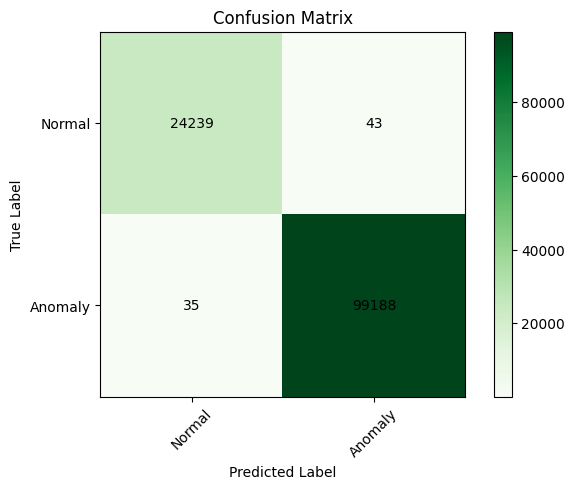

In [127]:
results = confusion_matrix(true_labels, pred_labels) 

print ('Confusion Matrix :')

def plot_confusion_matrix(cm, target_names, title='Confusion Matrix', cmap=plt.cm.Greens):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(target_names))
    plt.xticks(tick_marks, target_names, rotation=45)
    plt.yticks(tick_marks, target_names)
    plt.tight_layout()

    width, height = cm.shape

    for x in range(width):
        for y in range(height):
            plt.annotate(str(cm[x][y]), xy=(y, x), 
                        horizontalalignment='center',
                        verticalalignment='center')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')


plot_confusion_matrix(results, ['Normal','Anomaly'])

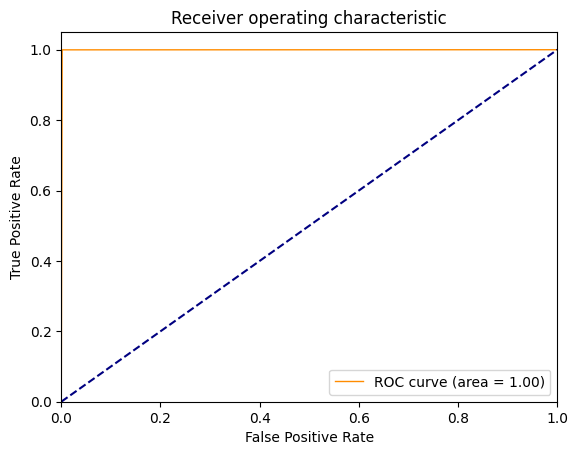

In [128]:
fpr, tpr, thresholds = roc_curve(true_labels, pred_labels)
roc_auc = roc_auc_score(true_labels, pred_labels)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=1, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

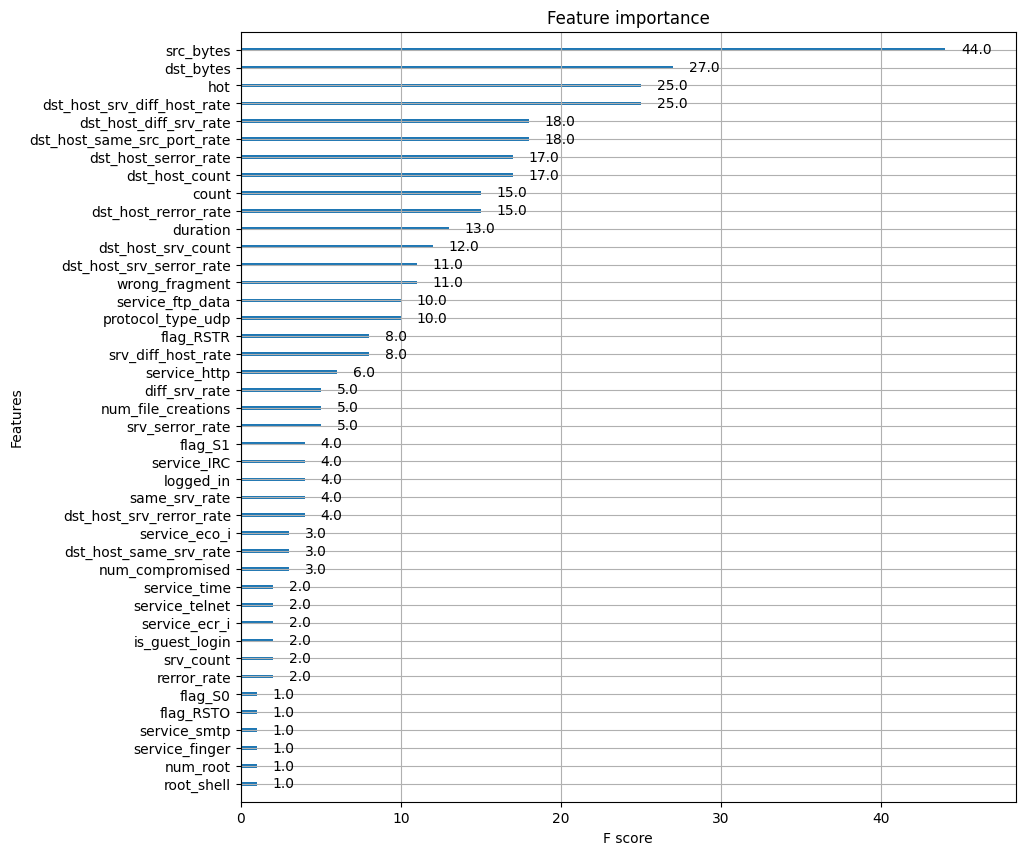

In [129]:
ax = xgb.plot_importance(model)
fig = ax.figure
fig.set_size_inches(10, 10)

# V. Multi-Class Classification Model [Exercise]

In [130]:
num_labels = len(le.classes_)
params['objective'] = 'multi:softprob'
params['num_class'] = num_labels
print(params)

# Nó dùng 1 bộ tham số duy nhất, nhưng bên trong mô hình này sẽ xây dựng n cây riêng cho mỗi lớp tại mỗi vòng boosting.
# It uses a single set of parameters, but inside this model, it builds n separate trees for each class in every boosting round.

{'max_depth': 8, 'max_leaves': 256, 'alpha': 0.9, 'eta': 0.1, 'gamma': 0.1, 'learning_rate': 0.1, 'subsample': 1, 'reg_lambda': 1, 'scale_pos_weight': 2, 'tree_method': 'hist', 'objective': 'multi:softprob', 'num_class': 23}


In [131]:
%%time 

dtrain = xgb.DMatrix(x_train, label=y_train)
dtest = xgb.DMatrix(x_test, label=y_test)
evals = [(dtest, 'test',), (dtrain, 'train')]
model = xgb.train(params, dtrain, num_rounds, evals=evals)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:160: UserWarning: [16:51:19] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "scale_pos_weight" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	test-mlogloss:2.03427	train-mlogloss:2.03412
[1]	test-mlogloss:1.67031	train-mlogloss:1.67012
[2]	test-mlogloss:1.42192	train-mlogloss:1.42170
[3]	test-mlogloss:1.23272	train-mlogloss:1.23247
[4]	test-mlogloss:1.08069	train-mlogloss:1.08042
[5]	test-mlogloss:0.95441	train-mlogloss:0.95419
[6]	test-mlogloss:0.84727	train-mlogloss:0.84707
[7]	test-mlogloss:0.75524	train-mlogloss:0.75504
[8]	test-mlogloss:0.67524	train-mlogloss:0.67504
[9]	test-mlogloss:0.60514	train-mlogloss:0.60493
CPU times: user 35.5 s, sys: 675 ms, total: 36.2 s
Wall time: 9.73 s


In [132]:
preds = model.predict(dtest)
pred_labels = np.argmax(preds, axis=1)
true_labels = y_test
print ('Accuracy Score :', accuracy_score(true_labels, pred_labels))

Accuracy Score : 0.9994413181652565


Confusion Matrix :


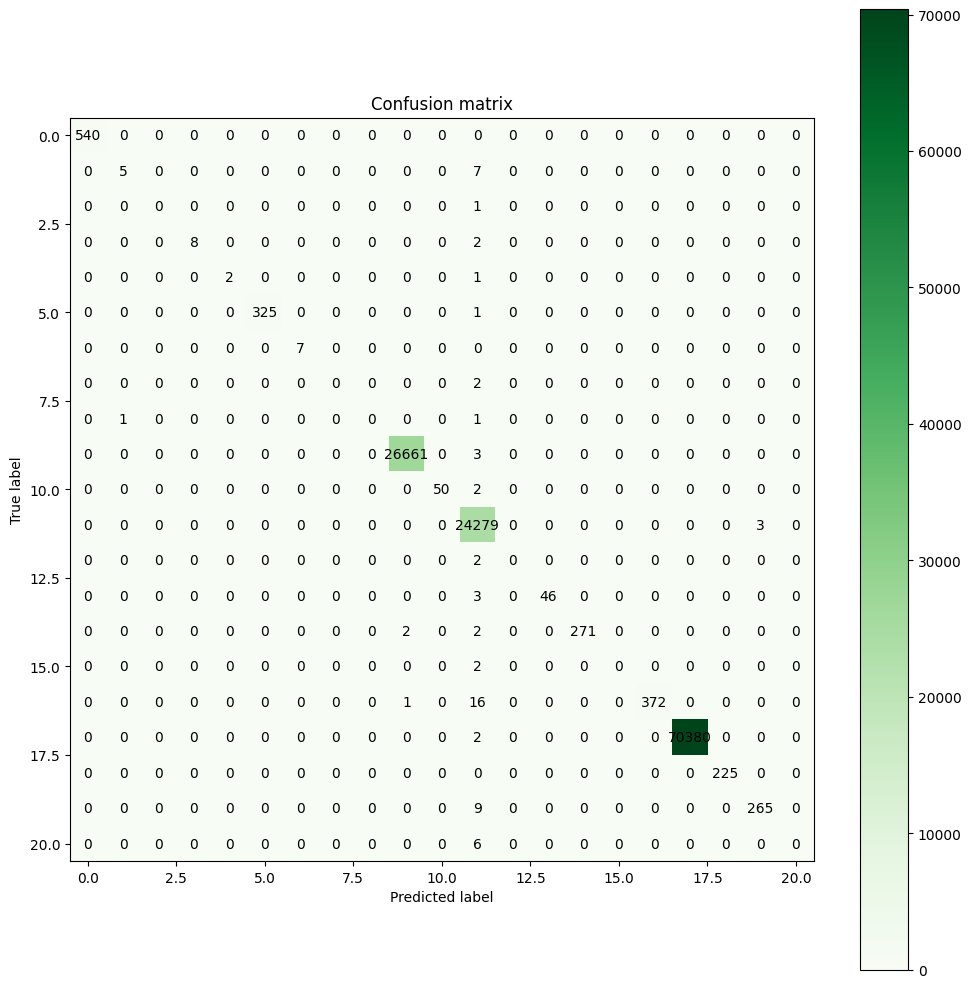

In [133]:
cm = confusion_matrix(true_labels, pred_labels)

print ('Confusion Matrix :')

def plot_confusion_matrix(cm, title='Confusion matrix', cmap=plt.cm.Greens):
    plt.figure(figsize=(10,10),)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    
    #tick_marks = np.arange(len(target_names))
    #plt.xticks(tick_marks, target_names, rotation=45)
    #plt.yticks(tick_marks, target_names)
    plt.tight_layout()

    width, height = cm.shape

    for x in range(width):
        for y in range(height):
            plt.annotate(str(cm[x][y]), xy=(y, x), 
                        horizontalalignment='center',
                        verticalalignment='center')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

plot_confusion_matrix(cm)